# Tutorial: ACLED Gaza NUTS on a truncated rolling 2-week task

This notebook isolates the `nuts_small` backend on a manageable ACLED subproblem.

We keep the same Gaza preprocessing and grid as the main tutorials, but only use the first 20 two-week bins. Within that truncated window, we now run the same rolling 1-step-ahead 2-week forecast task used in the other ACLED notebooks.

The point here is not speed. It is to inspect whether the MCMC fit looks healthy across rolling splits:

- divergence count
- `r_hat`
- effective sample size
- posterior stability diagnostics
- rolling held-out forecast behavior

In [1]:
import gc
import time
NB_START = time.perf_counter()

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.path import Path as MplPath

from motac import (
    CountsTensor,
    EventTable,
    FitConfig,
    GridSpec,
    HawkesModelSpec,
    MobilityHawkesModel,
    acled_to_counts,
)
from motac.connectivity import make_grid_stencil
from motac.eval import score_crps_counts, score_predictive_log_prob_samples

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("docs/tutorials/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())

JAX backend: gpu
Devices: [CudaDevice(id=0)]


## Load the ACLED Gaza snapshot and build the 14-day tensor

This section mirrors the earlier ACLED tutorials so that the NUTS experiment stays directly comparable.

In [2]:
snapshot_path = DATA_DIR / "acled_events_example.csv"
if not snapshot_path.exists():
    raise FileNotFoundError(f"Missing snapshot: {snapshot_path}")

GAZA_BOUNDARY_CACHE = DATA_DIR / "gaza_boundary.geojson"
DEFAULT_GAZA_BBOX = (34.2, 34.6, 31.2, 31.6)


def close_ring(coords: np.ndarray) -> np.ndarray:
    arr = np.asarray(coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("Polygon coordinates must have shape [N, 2].")
    if len(arr) < 3:
        raise ValueError("Polygon ring must contain at least 3 coordinates.")
    if not np.allclose(arr[0], arr[-1]):
        arr = np.vstack([arr, arr[0]])
    return arr


def ring_area(coords: np.ndarray) -> float:
    arr = close_ring(coords)
    x = arr[:, 0]
    y = arr[:, 1]
    return 0.5 * abs(np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:]))


def extract_outer_ring(geometry: dict[str, object]) -> np.ndarray:
    geom_type = geometry.get("type")
    coords = geometry.get("coordinates")
    if geom_type == "Polygon":
        return close_ring(np.asarray(coords[0], dtype=float))
    if geom_type == "MultiPolygon":
        rings = [close_ring(np.asarray(poly[0], dtype=float)) for poly in coords if poly]
        return max(rings, key=ring_area)
    raise ValueError(f"Unsupported boundary geometry type: {geom_type}")


def load_gaza_outline(boundary_path: Path, fallback_bbox: tuple[float, float, float, float]) -> np.ndarray:
    if boundary_path.exists():
        payload = json.loads(boundary_path.read_text())
        return extract_outer_ring(payload["features"][0]["geometry"])
    lon_min, lon_max, lat_min, lat_max = fallback_bbox
    return close_ring(np.array([[lon_min, lat_min], [lon_max, lat_min], [lon_max, lat_max], [lon_min, lat_max]], dtype=float))


def collapse_event_type(value: object) -> str:
    text = str(value)
    if text == "Explosions/Remote violence":
        return "Explosion"
    if text == "Battles":
        return "Battle"
    if text in {"Riots", "Protests"}:
        return "Riot/Protest"
    if text == "Violence against civilians":
        return "VAC"
    return "Other"


def apply_gaza_mask(arr_2d: np.ndarray) -> np.ndarray:
    masked = np.asarray(arr_2d, dtype=float).copy()
    masked[~gaza_mask] = np.nan
    return masked


def flatten_masked_counts(y: np.ndarray) -> np.ndarray:
    arr = np.asarray(y)
    if arr.ndim == 3:
        return arr[:, gaza_mask_flat, :]
    if arr.ndim == 4:
        return arr[:, :, gaza_mask_flat, :]
    raise ValueError(f"Unexpected tensor rank: {arr.ndim}")


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).reshape(-1)
    b_flat = np.asarray(b, dtype=float).reshape(-1)
    finite = np.isfinite(a_flat) & np.isfinite(b_flat)
    if finite.sum() < 2:
        return float("nan")
    a_use = a_flat[finite]
    b_use = b_flat[finite]
    if np.std(a_use) < 1e-8 or np.std(b_use) < 1e-8:
        return float("nan")
    return float(np.corrcoef(a_use, b_use)[0, 1])


def draw_gaza_outline_projected(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    ax.plot(gaza_outline_xy[:, 0], gaza_outline_xy[:, 1], color=color, linewidth=linewidth, alpha=alpha)


gaza_outline_lonlat = load_gaza_outline(GAZA_BOUNDARY_CACHE, DEFAULT_GAZA_BBOX)
gaza_path_lonlat = MplPath(gaza_outline_lonlat)
GAZA_BBOX = (
    float(gaza_outline_lonlat[:, 0].min()),
    float(gaza_outline_lonlat[:, 0].max()),
    float(gaza_outline_lonlat[:, 1].min()),
    float(gaza_outline_lonlat[:, 1].max()),
)

EARTH_RADIUS_M = 6_371_000.0
center_lon = 0.5 * (GAZA_BBOX[0] + GAZA_BBOX[1])
center_lat = 0.5 * (GAZA_BBOX[2] + GAZA_BBOX[3])
cos_center_lat = np.cos(np.deg2rad(center_lat))


def lonlat_to_local_xy(lon: np.ndarray | float, lat: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    lon_arr = np.asarray(lon, dtype=float)
    lat_arr = np.asarray(lat, dtype=float)
    x = np.deg2rad(lon_arr - center_lon) * EARTH_RADIUS_M * cos_center_lat
    y = np.deg2rad(lat_arr - center_lat) * EARTH_RADIUS_M
    return x, y


_df_raw = pd.read_csv(snapshot_path, low_memory=False)
df = _df_raw.copy()
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.floor("D")
df = df.dropna(subset=["event_date", "latitude", "longitude", "event_type"]).copy()
df = df[
    df["longitude"].between(GAZA_BBOX[0], GAZA_BBOX[1])
    & df["latitude"].between(GAZA_BBOX[2], GAZA_BBOX[3])
].copy()
df = df.loc[gaza_path_lonlat.contains_points(df[["longitude", "latitude"]].to_numpy(dtype=float), radius=1e-9)].copy()

df["event_type_group"] = df["event_type"].map(collapse_event_type)
window_start = df["event_date"].max() - pd.Timedelta(days=730)
df = df[df["event_date"] >= window_start].copy()
top_marks = df["event_type_group"].value_counts().head(4).index.tolist()
df = df[df["event_type_group"].isin(top_marks)].copy().sort_values("event_date").reset_index(drop=True)

proj_x, proj_y = lonlat_to_local_xy(df["longitude"].to_numpy(dtype=float), df["latitude"].to_numpy(dtype=float))
df_model = df.rename(columns={"event_type_group": "event_type_model"}).copy()
df_model["x_proj"] = proj_x
df_model["y_proj"] = proj_y

gaza_outline_x, gaza_outline_y = lonlat_to_local_xy(gaza_outline_lonlat[:, 0], gaza_outline_lonlat[:, 1])
gaza_outline_xy = np.column_stack([gaza_outline_x, gaza_outline_y])
gaza_path_xy = MplPath(gaza_outline_xy)
x_min = float(gaza_outline_xy[:, 0].min())
x_max = float(gaza_outline_xy[:, 0].max())
y_min = float(gaza_outline_xy[:, 1].min())
y_max = float(gaza_outline_xy[:, 1].max())
projected_extent = (x_min, x_max, y_min, y_max)

cell_size_m = 1_000.0
n_cols = max(1, int(np.ceil((x_max - x_min) / cell_size_m)))
n_rows = max(1, int(np.ceil((y_max - y_min) / cell_size_m)))
grid = GridSpec(shape=(n_rows, n_cols), extent=projected_extent, crs="LOCAL_GAZA_EQUIRECT_M")
H, W = grid.shape

x_edges = np.linspace(x_min, x_max, W + 1)
y_edges = np.linspace(y_min, y_max, H + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
grid_xx, grid_yy = np.meshgrid(x_centers, y_centers, indexing="xy")
gaza_mask = gaza_path_xy.contains_points(
    np.column_stack([grid_xx.reshape(-1), grid_yy.reshape(-1)]),
    radius=1e-9,
).reshape(H, W)
gaza_mask_flat = gaza_mask.reshape(-1)

events = EventTable(
    df=df_model,
    time_col="event_date",
    lat_col="y_proj",
    lon_col="x_proj",
    mark_col="event_type_model",
)
counts_base = acled_to_counts(events, grid, marks=top_marks, dt_days=14)
counts_agnostic = counts_base.with_connectivity(make_grid_stencil(kind="gaussian", size=3, sigma=1.0))

print("Rows after Gaza filter:", len(df))
print("Marks:", counts_agnostic.marks)
print("Tensor shape [T, J, M]:", counts_agnostic.y.shape)
print("Cells inside Gaza mask:", int(gaza_mask.sum()), "/", int(gaza_mask.size))

Rows after Gaza filter: 15561
Marks: ('Explosion', 'Battle', 'Other', 'VAC')
Tensor shape [T, J, M]: (33, 1428, 4)
Cells inside Gaza mask: 388 / 1428


## Build the truncated rolling 2-week task

We still restrict the experiment to the first 20 two-week bins so the `nuts_small` size guard remains satisfied.

But instead of using only the final bin as a single hold-out, we now evaluate the same rolling task as the other ACLED notebooks:

- fit on the first 2 weeks, forecast the next 2 weeks
- fit on the first 4 weeks, forecast the next 2 weeks
- continue one bin at a time through the truncated 20-bin window

On a 14-day tensor this is still `horizon=1`, `step=1`, with a rolling `min_train` choice.

Truncated tensor shape: (20, 1428, 4)
Rolling splits (2-week task): 19
Representative split ids for plotting: [0, 9, 18]
Largest train t * j in truncated rolling task: 27132


,split,train_bins,test_bins,train_tj,train_start,train_end,test_start,test_end,true_total
0,0,1,1,1428,2023-09-05,2023-09-18,2023-09-19,2023-10-02,18.0
1,1,2,1,2856,2023-09-05,2023-10-02,2023-10-03,2023-10-16,330.0
2,2,3,1,4284,2023-09-05,2023-10-16,2023-10-17,2023-10-30,559.0
3,3,4,1,5712,2023-09-05,2023-10-30,2023-10-31,2023-11-13,719.0
4,4,5,1,7140,2023-09-05,2023-11-13,2023-11-14,2023-11-27,493.0
5,5,6,1,8568,2023-09-05,2023-11-27,2023-11-28,2023-12-11,564.0
6,6,7,1,9996,2023-09-05,2023-12-11,2023-12-12,2023-12-25,632.0
7,7,8,1,11424,2023-09-05,2023-12-25,2023-12-26,2024-01-08,607.0


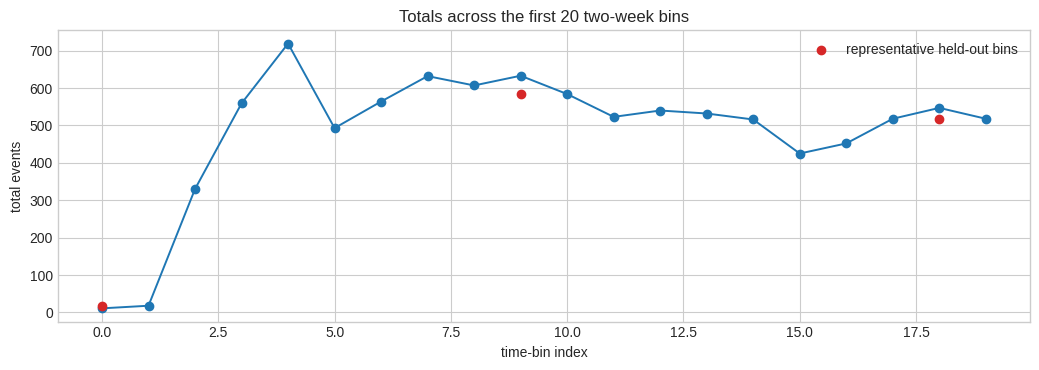

In [3]:
counts_20 = CountsTensor(
    y=counts_agnostic.y[:20],
    t0=counts_agnostic.t0,
    dt_days=counts_agnostic.dt_days,
    num_time=20,
    num_nodes=counts_agnostic.num_nodes,
    marks=counts_agnostic.marks,
    node_coords=counts_agnostic.node_coords,
    grid=counts_agnostic.grid,
    connectivity=counts_agnostic.connectivity,
    covariates=counts_agnostic.covariates,
)

rolling_splits = counts_20.rolling_origin_splits(horizon=1, step=1, min_train=1)

split_rows = []
for split_id, split in enumerate(rolling_splits):
    train_start = pd.Timestamp(split.train.t0)
    train_end = train_start + pd.Timedelta(days=int(split.train.dt_days) * int(split.train.num_time)) - pd.Timedelta(days=1)
    test_start = pd.Timestamp(split.test.t0)
    test_end = test_start + pd.Timedelta(days=int(split.test.dt_days) * int(split.test.num_time)) - pd.Timedelta(days=1)
    split_rows.append(
        {
            "split": split_id,
            "train_bins": int(split.train.num_time),
            "test_bins": int(split.test.num_time),
            "train_tj": int(split.train.num_time * split.train.num_nodes),
            "train_start": train_start.date(),
            "train_end": train_end.date(),
            "test_start": test_start.date(),
            "test_end": test_end.date(),
            "true_total": float(np.asarray(split.test.y).sum()),
        }
    )

split_table = pd.DataFrame(split_rows)
plot_split_ids = sorted(set([0, len(rolling_splits) // 2, len(rolling_splits) - 1]))

bin_totals = np.asarray(counts_20.y).sum(axis=(1, 2))

print("Truncated tensor shape:", counts_20.y.shape)
print("Rolling splits (2-week task):", len(rolling_splits))
print("Representative split ids for plotting:", plot_split_ids)
print("Largest train t * j in truncated rolling task:", int(split_table["train_tj"].max()))
display(split_table.head(8))

fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.plot(np.arange(len(bin_totals)), bin_totals, marker="o", linewidth=1.4)
ax.scatter(plot_split_ids, split_table.loc[plot_split_ids, "true_total"], color="tab:red", zorder=3, label="representative held-out bins")
ax.set_title("Totals across the first 20 two-week bins")
ax.set_xlabel("time-bin index")
ax.set_ylabel("total events")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
plt.close(fig)

## Run the full truncated rolling 2-week NUTS backtest

This keeps the same NUTS configuration, but applies it to every rolling 1-step-ahead split available inside the first 20 bins.

That gives the same evaluation structure as the other ACLED notebooks while still respecting the truncated problem size.

In [4]:
def cleanup_memory() -> None:
    gc.collect()
    jax.clear_caches()


nuts_spec = HawkesModelSpec(
    marks=counts_20.marks,
    temporal_bases=2,
    observation="nb2",
)

nuts_cfg = FitConfig(
    nuts_warmup=400,
    nuts_samples=400,
    nuts_chains=2,
    nuts_target_accept=0.9,
    nuts_max_tj=35_000,
)


def retained_lookup(backtest_result: dict[str, object]) -> dict[int, dict[str, object]]:
    return {int(item["split"]): item for item in backtest_result["retained"]}


def run_truncated_nuts_backtest(
    counts: CountsTensor,
    *,
    fit_config: FitConfig,
    forecast_samples: int,
    seed: int,
) -> dict[str, object]:
    model = MobilityHawkesModel(nuts_spec)
    splits = counts.rolling_origin_splits(horizon=1, step=1, min_train=1)

    rows = []
    retained = []
    for split_id, split in enumerate(splits):
        fit = model.fit(split.train, method="nuts_small", config=fit_config, seed=seed + split_id)
        forecast = model.forecast(
            split.train,
            fit,
            horizon=1,
            num_samples=forecast_samples,
            seed=seed + 10_000 + split_id,
        )

        nuts_diag = fit.diagnostics
        posterior_grouped = nuts_diag["posterior_samples_grouped"]

        y_true = np.asarray(split.test.y)
        y_pred = np.asarray(forecast.mean)
        y_samples = np.asarray(forecast.y_samples)

        observed_map = apply_gaza_mask(y_true.sum(axis=(0, 2)).reshape(H, W))
        predicted_map = apply_gaza_mask(y_pred.sum(axis=(0, 2)).reshape(H, W))
        err_map = predicted_map - observed_map

        train_start = pd.Timestamp(split.train.t0)
        train_end = train_start + pd.Timedelta(days=int(split.train.dt_days) * int(split.train.num_time)) - pd.Timedelta(days=1)
        test_start = pd.Timestamp(split.test.t0)
        test_end = test_start + pd.Timedelta(days=int(split.test.dt_days) * int(split.test.num_time)) - pd.Timedelta(days=1)

        rows.append(
            {
                "split": split_id,
                "train_bins": int(split.train.num_time),
                "train_tj": int(split.train.num_time * split.train.num_nodes),
                "train_start": train_start,
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "heldout_total_true": float(y_true.sum()),
                "heldout_total_pred": float(y_pred.sum()),
                "heldout_abs_total_err": float(abs(y_pred.sum() - y_true.sum())),
                "heldout_masked_log_score": float(
                    score_predictive_log_prob_samples(
                        flatten_masked_counts(y_true),
                        flatten_masked_counts(y_samples),
                    )
                ),
                "heldout_masked_crps": float(
                    score_crps_counts(
                        flatten_masked_counts(y_true),
                        flatten_masked_counts(y_samples),
                    )
                ),
                "heldout_masked_spatial_corr": float(safe_corr(observed_map, predicted_map)),
                "heldout_masked_spatial_rmse": float(np.sqrt(np.nanmean(err_map**2))),
                "num_divergences": int(nuts_diag["num_divergences"]),
                "divergence_fraction": float(nuts_diag["divergence_fraction"]),
                "summary_r_hat_max": float(nuts_diag["summary_r_hat_max"]),
                "summary_r_hat_median": float(nuts_diag["summary_r_hat_median"]),
                "summary_n_eff_min": float(nuts_diag["summary_n_eff_min"]),
                "excitation_spectral_radius_mean": float(nuts_diag["excitation_spectral_radius_mean"]),
                "excitation_subcritical_fraction": float(nuts_diag["excitation_subcritical_fraction"]),
            }
        )

        retained.append(
            {
                "split": split_id,
                "train_bins": int(split.train.num_time),
                "test_t0": pd.Timestamp(split.test.t0),
                "dt_days": int(split.test.dt_days),
                "test_y": y_true.astype(np.float32),
                "pred_mean": y_pred.astype(np.float32),
                "trace_mu0": np.asarray(posterior_grouped["mu"])[:, :, 0].astype(np.float32),
                "trace_alpha0": np.asarray(posterior_grouped["alpha"])[:, :, 0].astype(np.float32),
                "trace_phi0": np.asarray(posterior_grouped["phi"])[:, :, 0].astype(np.float32),
                "diag": {
                    "num_divergences": int(nuts_diag["num_divergences"]),
                    "summary_r_hat_max": float(nuts_diag["summary_r_hat_max"]),
                    "summary_n_eff_min": float(nuts_diag["summary_n_eff_min"]),
                    "excitation_spectral_radius_mean": float(nuts_diag["excitation_spectral_radius_mean"]),
                    "excitation_subcritical_fraction": float(nuts_diag["excitation_subcritical_fraction"]),
                },
            }
        )

        print(f"nuts_small_nb2_truncated: finished split {split_id + 1}/{len(splits)}")
        del fit, forecast, nuts_diag, posterior_grouped, y_true, y_pred, y_samples, observed_map, predicted_map, err_map
        cleanup_memory()

    return {
        "scenario": "nuts_small_nb2_truncated",
        "summary": pd.DataFrame(rows),
        "retained": retained,
    }


nuts_bt = run_truncated_nuts_backtest(
    counts_20,
    fit_config=nuts_cfg,
    forecast_samples=128,
    seed=2026,
)
backtest_df = nuts_bt["summary"].copy()
backtest_df.head()

/home/oj/GoogleDrive/AcademicWork/Imperial/git/motac3/motac/infer.py:331: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


nuts_small_nb2_truncated: finished split 1/19
nuts_small_nb2_truncated: finished split 2/19
nuts_small_nb2_truncated: finished split 3/19
nuts_small_nb2_truncated: finished split 4/19
nuts_small_nb2_truncated: finished split 5/19
nuts_small_nb2_truncated: finished split 6/19
nuts_small_nb2_truncated: finished split 7/19
nuts_small_nb2_truncated: finished split 8/19
nuts_small_nb2_truncated: finished split 9/19
nuts_small_nb2_truncated: finished split 10/19
nuts_small_nb2_truncated: finished split 11/19
nuts_small_nb2_truncated: finished split 12/19
nuts_small_nb2_truncated: finished split 13/19
nuts_small_nb2_truncated: finished split 14/19
nuts_small_nb2_truncated: finished split 15/19
nuts_small_nb2_truncated: finished split 16/19
nuts_small_nb2_truncated: finished split 17/19
nuts_small_nb2_truncated: finished split 18/19
nuts_small_nb2_truncated: finished split 19/19


,split,train_bins,train_tj,train_start,train_end,test_start,test_end,heldout_total_true,heldout_total_pred,heldout_abs_total_err,...,heldout_masked_crps,heldout_masked_spatial_corr,heldout_masked_spatial_rmse,num_divergences,divergence_fraction,summary_r_hat_max,summary_r_hat_median,summary_n_eff_min,excitation_spectral_radius_mean,excitation_subcritical_fraction
0,0,1,1428,2023-09-05,2023-09-18,2023-09-19,2023-10-02,18.0,27.250000,9.250000,...,0.011134,0.467779,0.313318,0,0.0,1.004575,0.998693,720.381791,1.270163,0.35125
1,1,2,2856,2023-09-05,2023-10-02,2023-10-03,2023-10-16,330.0,30.007812,299.992188,...,0.209153,0.325730,2.889720,0,0.0,1.005707,0.998854,591.797531,1.489918,0.14875
2,2,3,4284,2023-09-05,2023-10-16,2023-10-17,2023-10-30,559.0,319.046875,239.953125,...,0.332438,0.460711,4.067504,0,0.0,1.002592,0.999330,702.238701,2.028475,0.02750
3,3,4,5712,2023-09-05,2023-10-30,2023-10-31,2023-11-13,719.0,673.890625,45.109375,...,0.408536,0.454551,5.278488,0,0.0,1.004651,0.998544,738.242004,2.407067,0.00000
4,4,5,7140,2023-09-05,2023-11-13,2023-11-14,2023-11-27,493.0,1103.828125,610.828125,...,0.275425,0.582217,3.801041,0,0.0,1.008147,0.999329,433.197941,4.337219,0.00000


## Inspect rolling NUTS diagnostics

The table below summarizes convergence and forecast behavior across all truncated rolling splits.

For this notebook, the most important questions are:

- which splits mix poorly?
- do divergences appear anywhere in the rolling task?
- how stable are the held-out totals and masked spatial scores across time?

In [5]:
display(
    backtest_df[
        [
            "split",
            "train_bins",
            "train_tj",
            "test_start",
            "test_end",
            "heldout_total_true",
            "heldout_total_pred",
            "heldout_abs_total_err",
            "heldout_masked_crps",
            "heldout_masked_spatial_corr",
            "summary_r_hat_max",
            "summary_n_eff_min",
            "num_divergences",
        ]
    ].head(8)
)

print("Worst splits by r_hat:")
display(
    backtest_df[
        [
            "split",
            "train_bins",
            "heldout_total_true",
            "heldout_total_pred",
            "heldout_masked_crps",
            "heldout_masked_spatial_corr",
            "summary_r_hat_max",
            "summary_n_eff_min",
            "num_divergences",
        ]
    ]
    .sort_values(["summary_r_hat_max", "summary_n_eff_min"], ascending=[False, True])
    .head(10)
)

rolling_summary = pd.DataFrame(
    {
        "metric": [
            "num_splits",
            "max_r_hat",
            "median_r_hat",
            "min_n_eff",
            "total_divergences",
            "mean_masked_crps",
            "mean_masked_spatial_corr",
            "mean_abs_total_err",
        ],
        "value": [
            int(len(backtest_df)),
            float(backtest_df["summary_r_hat_max"].max()),
            float(backtest_df["summary_r_hat_max"].median()),
            float(backtest_df["summary_n_eff_min"].min()),
            int(backtest_df["num_divergences"].sum()),
            float(backtest_df["heldout_masked_crps"].mean()),
            float(backtest_df["heldout_masked_spatial_corr"].mean()),
            float(backtest_df["heldout_abs_total_err"].mean()),
        ],
    }
)

print("Rolling-task summary:")
display(rolling_summary)

peak_split = int(backtest_df.sort_values("heldout_total_true", ascending=False).iloc[0]["split"])
late_split = int(backtest_df["split"].max())
worst_rhat_split = int(backtest_df.sort_values(["summary_r_hat_max", "summary_n_eff_min"], ascending=[False, True]).iloc[0]["split"])
selected_split_ids = sorted(set([peak_split, late_split, worst_rhat_split]))
print("Representative split ids:", selected_split_ids)

,split,train_bins,train_tj,test_start,test_end,heldout_total_true,heldout_total_pred,heldout_abs_total_err,heldout_masked_crps,heldout_masked_spatial_corr,summary_r_hat_max,summary_n_eff_min,num_divergences
0,0,1,1428,2023-09-19,2023-10-02,18.0,27.250000,9.250000,0.011134,0.467779,1.004575,720.381791,0
1,1,2,2856,2023-10-03,2023-10-16,330.0,30.007812,299.992188,0.209153,0.325730,1.005707,591.797531,0
2,2,3,4284,2023-10-17,2023-10-30,559.0,319.046875,239.953125,0.332438,0.460711,1.002592,702.238701,0
3,3,4,5712,2023-10-31,2023-11-13,719.0,673.890625,45.109375,0.408536,0.454551,1.004651,738.242004,0
4,4,5,7140,2023-11-14,2023-11-27,493.0,1103.828125,610.828125,0.275425,0.582217,1.008147,433.197941,0
5,5,6,8568,2023-11-28,2023-12-11,564.0,855.000000,291.000000,0.307855,0.475864,1.003944,464.359730,0
6,6,7,9996,2023-12-12,2023-12-25,632.0,820.328125,188.328125,0.335074,0.576222,1.002184,633.329926,0
7,7,8,11424,2023-12-26,2024-01-08,607.0,731.265625,124.265625,0.326210,0.485633,1.005584,634.121811,0


Worst splits by r_hat:


,split,train_bins,heldout_total_true,heldout_total_pred,heldout_masked_crps,heldout_masked_spatial_corr,summary_r_hat_max,summary_n_eff_min,num_divergences
17,17,18,547.0,547.398438,0.292559,0.505086,1.432247,2.296645,0
18,18,19,518.0,567.226562,0.282811,0.379383,1.422760,7.637154,0
10,10,11,523.0,722.187500,0.278769,0.498223,1.248171,12.915721,0
14,14,15,425.0,556.703125,0.229267,0.502123,1.133655,23.990337,0
11,11,12,540.0,672.304688,0.284956,0.529818,1.083263,21.109313,0
16,16,17,518.0,490.585938,0.284607,0.412233,1.065504,20.871544,0
15,15,16,452.0,506.523438,0.240093,0.544670,1.054888,53.452098,0
9,9,10,584.0,719.007812,0.308751,0.545950,1.018057,392.900402,0
12,12,13,532.0,653.859375,0.277914,0.542960,1.017820,36.494575,0
13,13,14,516.0,615.882812,0.272192,0.527063,1.016703,39.207043,0


Rolling-task summary:


,metric,value
0,num_splits,19.000000
1,max_r_hat,1.432247
2,median_r_hat,1.016703
3,min_n_eff,2.296645
4,total_divergences,0.000000
5,mean_masked_crps,0.278576
6,mean_masked_spatial_corr,0.492401
7,mean_abs_total_err,151.480674


Representative split ids: [3, 17, 18]


## Rolling totals, convergence trends, and representative spatial forecasts

The next cells summarize three things:

- rolling held-out totals and forecast scores
- how `r_hat`, `n_eff`, and subcriticality move across splits
- representative trace plots and side-by-side spatial maps for a few informative splits

The spatial plotting code uses a dedicated colourbar axis rather than `tight_layout()` over a shared colorbar, which avoids the bad rendering seen in the earlier version.

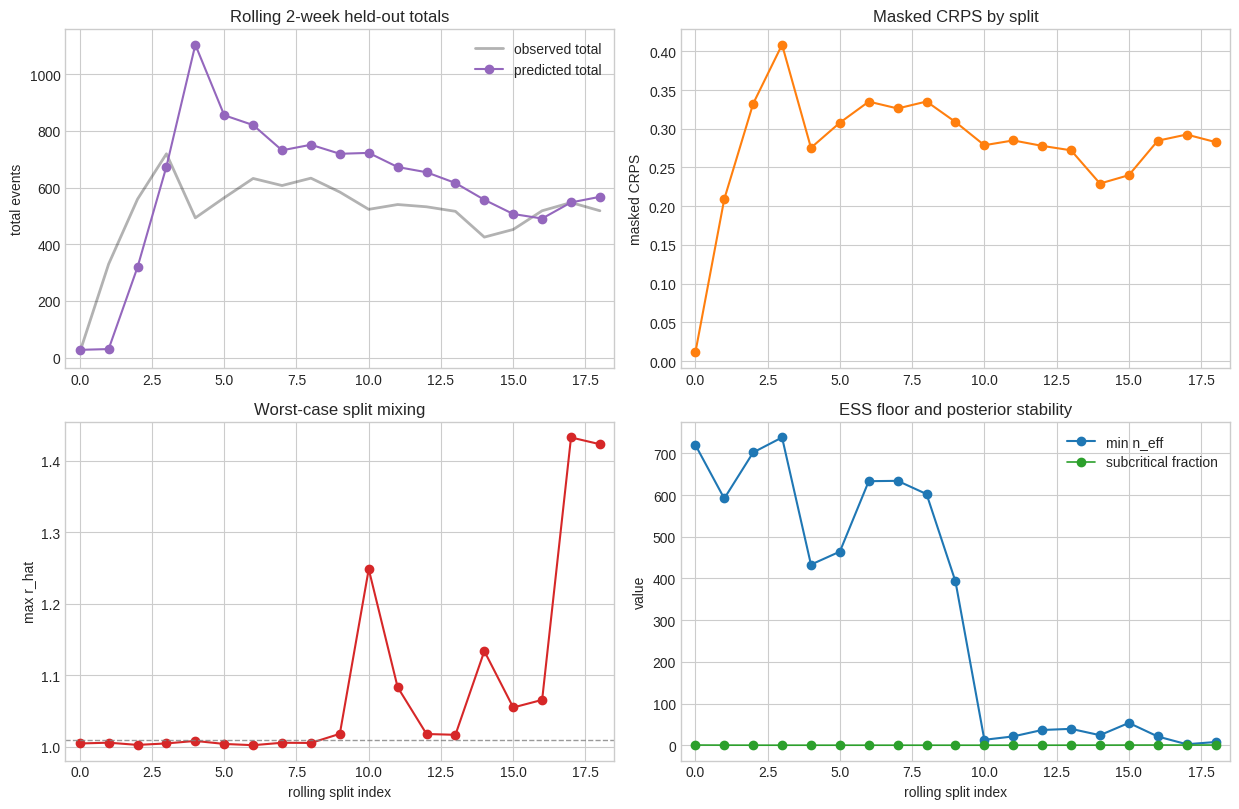

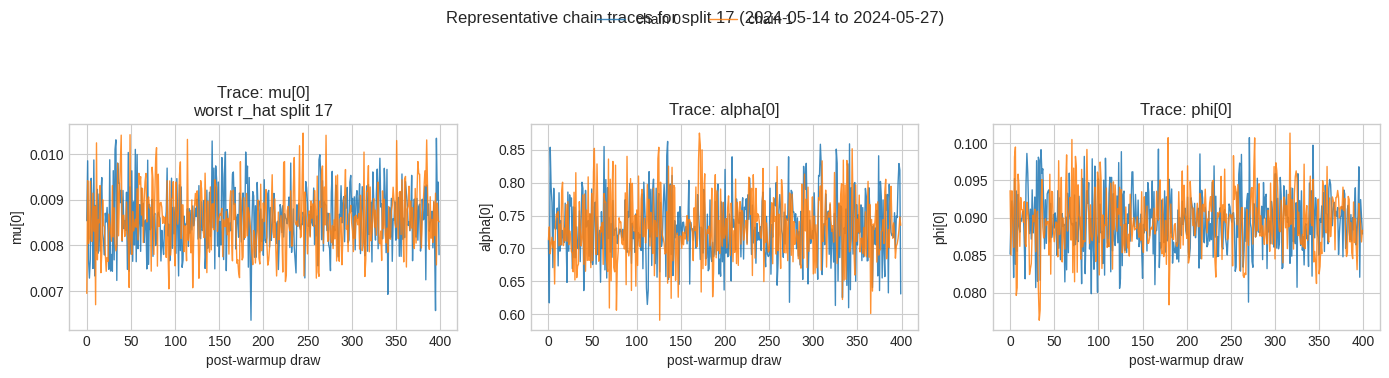

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2), squeeze=False)

axes[0, 0].plot(backtest_df["split"], backtest_df["heldout_total_true"], color="black", linewidth=2.0, alpha=0.3, label="observed total")
axes[0, 0].plot(backtest_df["split"], backtest_df["heldout_total_pred"], marker="o", linewidth=1.5, color="tab:purple", label="predicted total")
axes[0, 0].set_title("Rolling 2-week held-out totals")
axes[0, 0].set_ylabel("total events")
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(backtest_df["split"], backtest_df["heldout_masked_crps"], marker="o", linewidth=1.5, color="tab:orange")
axes[0, 1].set_title("Masked CRPS by split")
axes[0, 1].set_ylabel("masked CRPS")

axes[1, 0].plot(backtest_df["split"], backtest_df["summary_r_hat_max"], marker="o", linewidth=1.5, color="tab:red", label="max r_hat")
axes[1, 0].axhline(1.01, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
axes[1, 0].set_title("Worst-case split mixing")
axes[1, 0].set_ylabel("max r_hat")
axes[1, 0].set_xlabel("rolling split index")

axes[1, 1].plot(backtest_df["split"], backtest_df["summary_n_eff_min"], marker="o", linewidth=1.5, color="tab:blue", label="min n_eff")
axes[1, 1].plot(backtest_df["split"], backtest_df["excitation_subcritical_fraction"], marker="o", linewidth=1.2, color="tab:green", label="subcritical fraction")
axes[1, 1].set_title("ESS floor and posterior stability")
axes[1, 1].set_ylabel("value")
axes[1, 1].set_xlabel("rolling split index")
axes[1, 1].legend(frameon=False)

for ax in axes.flat:
    ax.set_xlim(-0.5, backtest_df["split"].max() + 0.5)

plt.tight_layout()
plt.show()
plt.close(fig)

rep_item = retained_lookup(nuts_bt)[worst_rhat_split]
rep_test_start = pd.Timestamp(rep_item["test_t0"])
rep_test_end = rep_test_start + pd.Timedelta(days=int(rep_item["dt_days"])) - pd.Timedelta(days=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
for chain_id in range(rep_item["trace_mu0"].shape[0]):
    axes[0].plot(rep_item["trace_mu0"][chain_id], alpha=0.85, linewidth=1.0, label=f"chain {chain_id}")
    axes[1].plot(rep_item["trace_alpha0"][chain_id], alpha=0.85, linewidth=1.0, label=f"chain {chain_id}")
    axes[2].plot(rep_item["trace_phi0"][chain_id], alpha=0.85, linewidth=1.0, label=f"chain {chain_id}")

axes[0].set_title(f"Trace: mu[0]\nworst r_hat split {worst_rhat_split}")
axes[0].set_ylabel("mu[0]")
axes[1].set_title("Trace: alpha[0]")
axes[1].set_ylabel("alpha[0]")
axes[2].set_title("Trace: phi[0]")
axes[2].set_ylabel("phi[0]")
for ax in axes:
    ax.set_xlabel("post-warmup draw")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
fig.suptitle(
    f"Representative chain traces for split {worst_rhat_split} ({rep_test_start.date()} to {rep_test_end.date()})",
    fontsize=12,
)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
plt.show()
plt.close(fig)

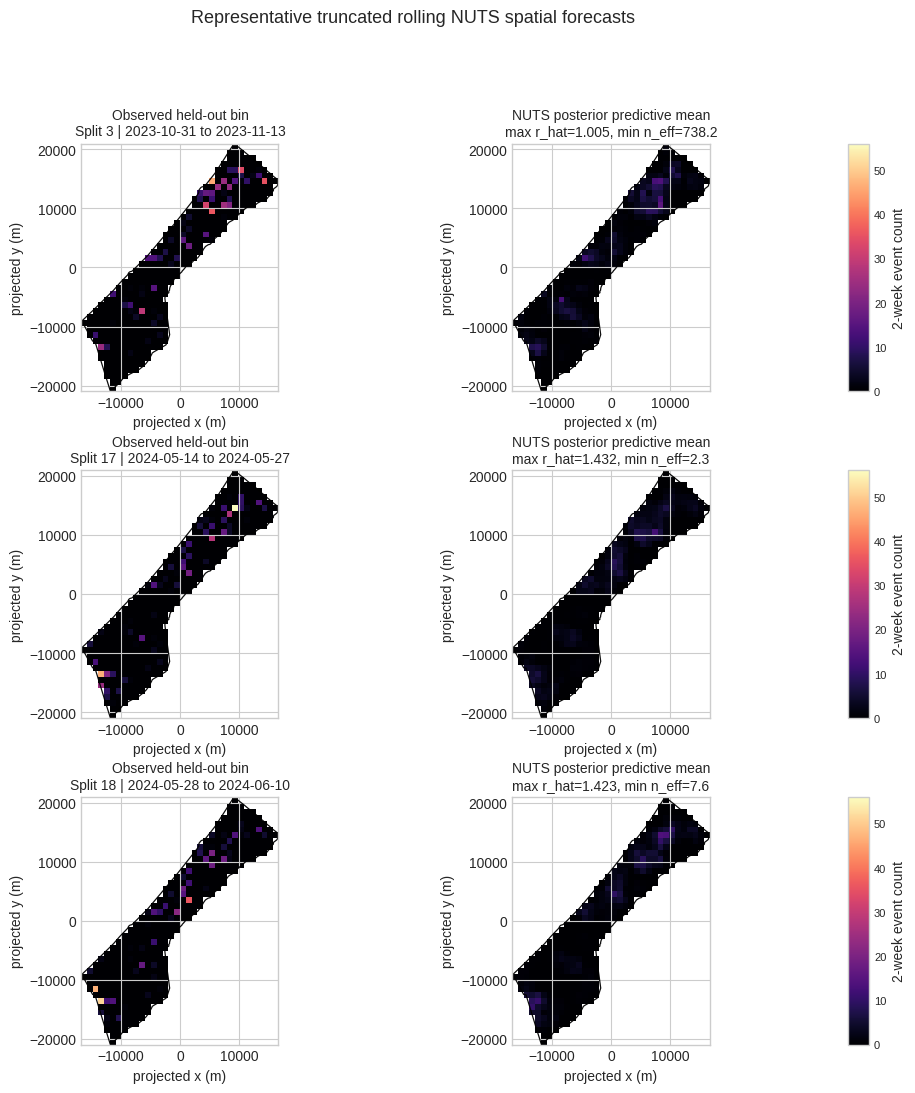

In [7]:
def plot_representative_pairs(backtest_result: dict[str, object], *, selected_splits: list[int]) -> None:
    lookup = retained_lookup(backtest_result)
    valid_ids = [split_id for split_id in selected_splits if split_id in lookup]
    if not valid_ids:
        print("No valid split ids selected for plotting.")
        return

    maps_for_scale = []
    for split_id in valid_ids:
        item = lookup[split_id]
        maps_for_scale.append(apply_gaza_mask(np.asarray(item["test_y"]).sum(axis=(0, 2)).reshape(H, W)))
        maps_for_scale.append(apply_gaza_mask(np.asarray(item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W)))
    vmax = max(max(float(np.nanmax(arr)), 1.0) for arr in maps_for_scale)

    fig = plt.figure(figsize=(11.4, 3.9 * len(valid_ids)))
    gs = fig.add_gridspec(len(valid_ids), 3, width_ratios=[1.0, 1.0, 0.055], wspace=0.16, hspace=0.32)

    for row_i, split_id in enumerate(valid_ids):
        item = lookup[split_id]
        observed_map = apply_gaza_mask(np.asarray(item["test_y"]).sum(axis=(0, 2)).reshape(H, W))
        predicted_map = apply_gaza_mask(np.asarray(item["pred_mean"]).sum(axis=(0, 2)).reshape(H, W))

        test_start = pd.Timestamp(item["test_t0"])
        test_end = test_start + pd.Timedelta(days=int(item["dt_days"])) - pd.Timedelta(days=1)
        diag = item["diag"]

        ax_obs = fig.add_subplot(gs[row_i, 0])
        ax_pred = fig.add_subplot(gs[row_i, 1])
        cax = fig.add_subplot(gs[row_i, 2])

        im = ax_obs.imshow(
            observed_map,
            cmap="magma",
            vmin=0.0,
            vmax=vmax,
            origin="lower",
            extent=projected_extent,
            aspect="equal",
        )
        ax_pred.imshow(
            predicted_map,
            cmap="magma",
            vmin=0.0,
            vmax=vmax,
            origin="lower",
            extent=projected_extent,
            aspect="equal",
        )

        draw_gaza_outline_projected(ax_obs, linewidth=0.9)
        draw_gaza_outline_projected(ax_pred, linewidth=0.9)

        ax_obs.set_title(f"Observed held-out bin\nSplit {split_id} | {test_start.date()} to {test_end.date()}", fontsize=10)
        ax_pred.set_title(
            "NUTS posterior predictive mean"
            f"\nmax r_hat={diag['summary_r_hat_max']:.3f}, min n_eff={diag['summary_n_eff_min']:.1f}",
            fontsize=10,
        )

        for ax in (ax_obs, ax_pred):
            ax.set_xlabel("projected x (m)")
            ax.set_ylabel("projected y (m)")

        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label("2-week event count")
        cbar.ax.tick_params(labelsize=8)

    fig.suptitle("Representative truncated rolling NUTS spatial forecasts", fontsize=13, y=0.995)
    plt.show()
    plt.close(fig)


plot_representative_pairs(nuts_bt, selected_splits=selected_split_ids)

## What to look for

For this truncated rolling NUTS notebook, the main success criteria are now split-level rather than single-fit:

- ideally no divergences on any split
- `summary_r_hat_max` staying close to 1 across splits
- `summary_n_eff_min` not collapsing on important parameters
- posterior excitation staying mostly subcritical
- held-out totals and spatial maps looking at least qualitatively plausible

If those fail, the next things to try are usually more warmup, a higher `nuts_target_accept`, or a smaller subproblem.

In [8]:
from motac import (
    aggregate_variant_counts_to_map,
    build_standard_acled_variants,
    flatten_variant_counts,
    summarise_variant_zero_mass,
)

variant_order = ["rect_1km", "gaza_1km", "gaza_2km"]
variant_labels = {
    "rect_1km": "1 km rectangular",
    "gaza_1km": "1 km Gaza-only",
    "gaza_2km": "2 km Gaza-only",
}

variant_dict = build_standard_acled_variants(
    events,
    marks=top_marks,
    polygon_xy=gaza_outline_xy,
    projected_extent=projected_extent,
    dt_days=14,
)


def truncate_counts_tensor(counts: CountsTensor, num_time: int) -> CountsTensor:
    return CountsTensor(
        y=counts.y[:num_time],
        t0=counts.t0,
        dt_days=counts.dt_days,
        num_time=num_time,
        num_nodes=counts.num_nodes,
        marks=counts.marks,
        node_coords=counts.node_coords,
        grid=counts.grid,
        connectivity=counts.connectivity,
        covariates=counts.covariates,
    )


truncated_variant_dict = {
    name: {
        "variant": variant_dict[name],
        "counts_20": truncate_counts_tensor(variant_dict[name].counts, 20),
    }
    for name in variant_order
}

variant_zero_df = (
    pd.DataFrame([summarise_variant_zero_mass(variant_dict[name]) for name in variant_order])
    .assign(label=lambda df_: df_["variant"].map(variant_labels))
    .set_index("variant")
)

display(
    variant_zero_df[
        [
            "label",
            "cell_size_m",
            "num_grid_cells",
            "num_gaza_cells",
            "num_model_nodes",
            "zero_fraction",
            "always_zero_node_fraction",
        ]
    ].round(3)
)

,label,cell_size_m,num_grid_cells,num_gaza_cells,num_model_nodes,zero_fraction,always_zero_node_fraction
variant,,,,,,,
rect_1km,1 km rectangular,1000.0,1428.0,388.0,1428.0,0.944,0.763
gaza_1km,1 km Gaza-only,1000.0,1428.0,388.0,388.0,0.944,0.763
gaza_2km,2 km Gaza-only,2000.0,357.0,95.0,95.0,0.821,0.368


In [9]:
def run_truncated_nuts_variant_backtest(
    variant,
    counts: CountsTensor,
    *,
    fit_config: FitConfig,
    forecast_samples: int,
    seed: int,
    min_train: int = 2,
) -> dict[str, object]:
    model = MobilityHawkesModel(nuts_spec)
    splits = counts.rolling_origin_splits(horizon=1, step=1, min_train=min_train)

    rows = []
    for split_id, split in enumerate(splits):
        fit = model.fit(split.train, method="nuts_small", config=fit_config, seed=seed + split_id)
        forecast = model.forecast(
            split.train,
            fit,
            horizon=1,
            num_samples=forecast_samples,
            seed=seed + 10_000 + split_id,
        )

        nuts_diag = fit.diagnostics
        y_true = np.asarray(split.test.y)
        y_pred = np.asarray(forecast.mean)
        y_samples = np.asarray(forecast.y_samples)

        observed_map = aggregate_variant_counts_to_map(variant, y_true)
        predicted_map = aggregate_variant_counts_to_map(variant, y_pred)
        err_map = predicted_map - observed_map

        rows.append(
            {
                "variant": variant.name,
                "split": split_id,
                "train_bins": int(split.train.num_time),
                "train_tj": int(split.train.num_time * split.train.num_nodes),
                "test_start": pd.Timestamp(split.test.t0),
                "heldout_total_true": float(y_true.sum()),
                "heldout_total_pred": float(y_pred.sum()),
                "heldout_abs_total_err": float(abs(y_pred.sum() - y_true.sum())),
                "heldout_masked_log_score": float(
                    score_predictive_log_prob_samples(
                        flatten_variant_counts(variant, y_true),
                        flatten_variant_counts(variant, y_samples),
                    )
                ),
                "heldout_masked_crps": float(
                    score_crps_counts(
                        flatten_variant_counts(variant, y_true),
                        flatten_variant_counts(variant, y_samples),
                    )
                ),
                "heldout_masked_spatial_corr": float(safe_corr(observed_map, predicted_map)),
                "heldout_masked_spatial_rmse": float(np.sqrt(np.nanmean(err_map**2))),
                "num_divergences": int(nuts_diag["num_divergences"]),
                "divergence_fraction": float(nuts_diag["divergence_fraction"]),
                "summary_r_hat_max": float(nuts_diag["summary_r_hat_max"]),
                "summary_r_hat_median": float(nuts_diag["summary_r_hat_median"]),
                "summary_n_eff_min": float(nuts_diag["summary_n_eff_min"]),
                "excitation_spectral_radius_mean": float(nuts_diag["excitation_spectral_radius_mean"]),
                "excitation_subcritical_fraction": float(nuts_diag["excitation_subcritical_fraction"]),
                "num_nodes": int(counts.num_nodes),
                "cell_size_m": float(variant.cell_size_m),
                "gaza_only": bool(variant.gaza_only),
            }
        )

        print(f"nuts_small_nb2_truncated_{variant.name}: finished split {split_id + 1}/{len(splits)}")
        del fit, forecast, nuts_diag, y_true, y_pred, y_samples, observed_map, predicted_map, err_map
        cleanup_memory()

    return {
        "variant": variant.name,
        "summary": pd.DataFrame(rows),
    }


variant_nuts_results = {}
for variant_id in variant_order:
    variant_payload = truncated_variant_dict[variant_id]
    variant = variant_payload["variant"]
    counts_20_variant = variant_payload["counts_20"]
    variant_nuts_results[variant_id] = run_truncated_nuts_variant_backtest(
        variant,
        counts_20_variant,
        fit_config=nuts_cfg,
        forecast_samples=128,
        seed=4026 + 100 * variant_order.index(variant_id),
        min_train=2,
    )
    cleanup_memory()

variant_nuts_summary = (
    pd.concat([variant_nuts_results[name]["summary"] for name in variant_order], ignore_index=True)
    .groupby("variant")
    [[
        "heldout_abs_total_err",
        "heldout_masked_log_score",
        "heldout_masked_crps",
        "heldout_masked_spatial_rmse",
        "heldout_masked_spatial_corr",
        "summary_r_hat_max",
        "summary_n_eff_min",
        "num_divergences",
        "excitation_spectral_radius_mean",
        "excitation_subcritical_fraction",
        "num_nodes",
        "train_tj",
    ]]
    .mean()
    .assign(label=lambda df_: [variant_labels[idx] for idx in df_.index])
    .sort_values(["heldout_masked_crps", "heldout_abs_total_err"])
)

display(
    variant_nuts_summary[
        [
            "label",
            "num_nodes",
            "train_tj",
            "heldout_abs_total_err",
            "heldout_masked_log_score",
            "heldout_masked_crps",
            "heldout_masked_spatial_rmse",
            "heldout_masked_spatial_corr",
            "summary_r_hat_max",
            "summary_n_eff_min",
            "num_divergences",
            "excitation_spectral_radius_mean",
            "excitation_subcritical_fraction",
        ]
    ].round(3)
)

print("Post-node-fix zero-heavy extension recommended next:", bool((variant_zero_df.loc[["gaza_1km", "gaza_2km"], "always_zero_node_fraction"] > 0.5).any()))

/home/oj/GoogleDrive/AcademicWork/Imperial/git/motac3/motac/infer.py:331: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


nuts_small_nb2_truncated_rect_1km: finished split 1/18
nuts_small_nb2_truncated_rect_1km: finished split 2/18
nuts_small_nb2_truncated_rect_1km: finished split 3/18
nuts_small_nb2_truncated_rect_1km: finished split 4/18
nuts_small_nb2_truncated_rect_1km: finished split 5/18
nuts_small_nb2_truncated_rect_1km: finished split 6/18
nuts_small_nb2_truncated_rect_1km: finished split 7/18
nuts_small_nb2_truncated_rect_1km: finished split 8/18
nuts_small_nb2_truncated_rect_1km: finished split 9/18
nuts_small_nb2_truncated_rect_1km: finished split 10/18
nuts_small_nb2_truncated_rect_1km: finished split 11/18
nuts_small_nb2_truncated_rect_1km: finished split 12/18
nuts_small_nb2_truncated_rect_1km: finished split 13/18
nuts_small_nb2_truncated_rect_1km: finished split 14/18
nuts_small_nb2_truncated_rect_1km: finished split 15/18
nuts_small_nb2_truncated_rect_1km: finished split 16/18
nuts_small_nb2_truncated_rect_1km: finished split 17/18
nuts_small_nb2_truncated_rect_1km: finished split 18/18
n

,label,num_nodes,train_tj,heldout_abs_total_err,heldout_masked_log_score,heldout_masked_crps,heldout_masked_spatial_rmse,heldout_masked_spatial_corr,summary_r_hat_max,summary_n_eff_min,num_divergences,excitation_spectral_radius_mean,excitation_subcritical_fraction
variant,,,,,,,,,,,,,
rect_1km,1 km rectangular,1428.0,14994.0,163.893,-0.315,0.294,3.978,0.482,1.112,344.075,0.0,1.581,0.092
gaza_1km,1 km Gaza-only,388.0,4074.0,243.026,-0.340,0.316,4.676,0.179,1.005,584.456,0.0,1.438,0.094
gaza_2km,2 km Gaza-only,95.0,997.5,124.735,-0.905,1.020,8.809,0.374,1.005,605.599,0.0,1.182,0.561


Post-node-fix zero-heavy extension recommended next: True


In [10]:
elapsed_sec = time.perf_counter() - NB_START
print(f"Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec / 60.0:.2f} minutes)")
print("Rolling splits:", int(len(backtest_df)))
print("Max split r_hat:", float(backtest_df["summary_r_hat_max"].max()))
print("Median split r_hat:", float(backtest_df["summary_r_hat_max"].median()))
print("Min split n_eff:", float(backtest_df["summary_n_eff_min"].min()))
print("Total divergences across splits:", int(backtest_df["num_divergences"].sum()))

Notebook wall-clock runtime: 8058.51 seconds (134.31 minutes)
Rolling splits: 19
Max split r_hat: 1.432247281074524
Median split r_hat: 1.0167025327682495
Min split n_eff: 2.29664471234966
Total divergences across splits: 0
